# Solar Power Generation Prediction using Linear Regression

## Use Case
This project predicts `AC_POWER` for a solar plant using inverter generation signals instead of a generic or house-price problem.
The mission is to support solar operations by estimating output from `DC_POWER`, `DAILY_YIELD`, and `TOTAL_YIELD`.
This is a specific renewable-energy regression use case tied to plant performance monitoring and short-term output estimation.


In [18]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

DATA_PATH = Path("Plant_1_Generation_Data.csv")
ARTIFACT_DIR = Path(".")
sns.set_theme(style="whitegrid")


## Data Loading and Exploration


In [19]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH.resolve()}")
df.head()


Loaded dataset from: /Users/manziivan453icloud.com/Downloads/Projects/linear_regression_model/summative/linear_regression/Plant_1_Generation_Data.csv


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [20]:
print("Dataset info:")
df.info()

print("\nBasic statistics:")
display(df.describe(include="all").T)


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB

Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DATE_TIME,68778,3158,01-06-2020 12:45,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PLANT_ID,68778.0,NaN,NaN,NaN,4135001.0,0.0,4135001.0,4135001.0,4135001.0,4135001.0,4135001.0
SOURCE_KEY,68778,22,bvBOhCH3iADSZry,3155,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DC_POWER,68778.0,NaN,NaN,NaN,3147.426211,4036.457169,0.0,0.0,429.0,6366.964286,14471.125
AC_POWER,68778.0,NaN,NaN,NaN,307.802752,394.396439,0.0,0.0,41.49375,623.61875,1410.95
DAILY_YIELD,68778.0,NaN,NaN,NaN,3295.968737,3145.178309,0.0,0.0,2658.714286,6274.0,9163.0
TOTAL_YIELD,68778.0,NaN,NaN,NaN,6978711.760671,416271.982856,6183645.0,6512002.53575,7146685.0,7268705.90625,7846821.0


In [21]:
numeric_columns = ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], format="%d-%m-%Y %H:%M", errors="coerce")

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Missing values before cleanup:")
display(df[numeric_columns + ["DATE_TIME"]].isna().sum().rename("missing_count"))

df = df.dropna(subset=numeric_columns).copy()
df = df[df["DC_POWER"] > 0].copy()

dropped_columns = ["DATE_TIME", "SOURCE_KEY", "PLANT_ID"]
df_model = df.drop(columns=dropped_columns, errors="ignore").copy()

print(f"Rows after numeric conversion and daytime filtering: {len(df_model):,}")
print(f"Dropped columns from the training matrix: {', '.join(dropped_columns)}")
df_model.head()


Missing values before cleanup:


DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
DATE_TIME      0
Name: missing_count, dtype: int64

Rows after numeric conversion and daytime filtering: 36,827
Dropped columns from the training matrix: DATE_TIME, SOURCE_KEY, PLANT_ID


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
510,37.142857,3.585714,0.0,6259559.0
511,53.500000,5.162500,0.0,6183645.0
512,58.000000,5.585714,0.0,6987759.0
513,58.428571,5.628571,0.0,7602960.0
514,54.375000,5.250000,0.0,7158964.0


## Feature Engineering

The feature engineering steps below make the dataset usable for regression:
- `DC_POWER`, `AC_POWER`, `DAILY_YIELD`, and `TOTAL_YIELD` are converted to numeric values.
- Rows with missing numeric values are removed.
- Night-time or no-generation rows are excluded by keeping only `DC_POWER > 0`.
- `DATE_TIME`, `PLANT_ID`, and `SOURCE_KEY` are dropped from the final training matrix because they are identifiers or non-model fields for this version of the model.


In [22]:
display(df_model.dtypes.rename("dtype").to_frame())
df = df_model.copy()


,dtype
DC_POWER,float64
AC_POWER,float64
DAILY_YIELD,float64
TOTAL_YIELD,float64


## Data Visualization


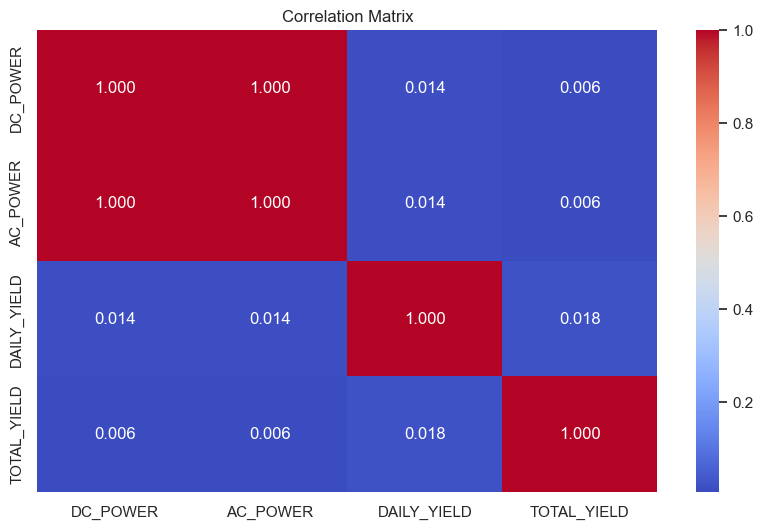

In [23]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Matrix")
plt.show()


### Interpretation

- `DC_POWER` has the strongest relationship with `AC_POWER`, so it is the main driver of this regression task.
- `DAILY_YIELD` and `TOTAL_YIELD` have weaker direct correlations, but they still provide extra operating context to the multivariate model.
- The heatmap and distribution plots justify keeping the three generation features while removing identifiers from training.


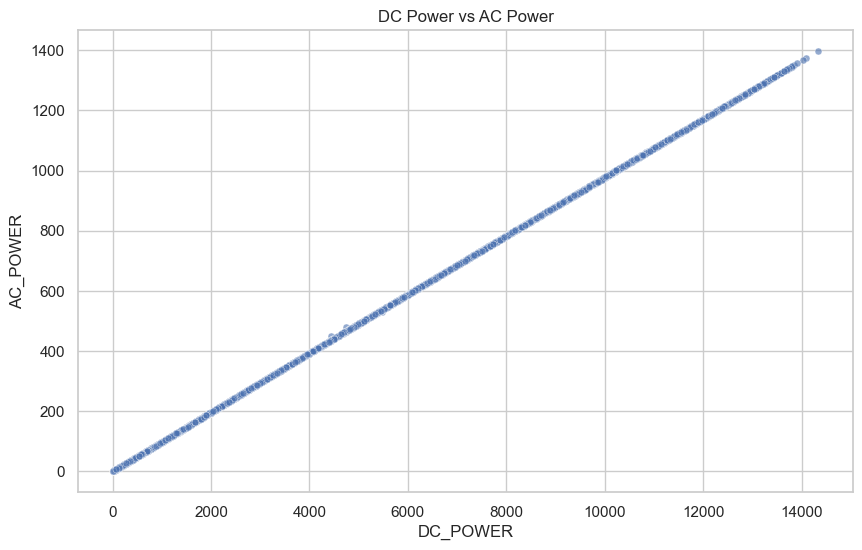

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(min(len(df), 5000), random_state=42), x="DC_POWER", y="AC_POWER", alpha=0.6, s=25)
plt.title("DC Power vs AC Power")
plt.show()


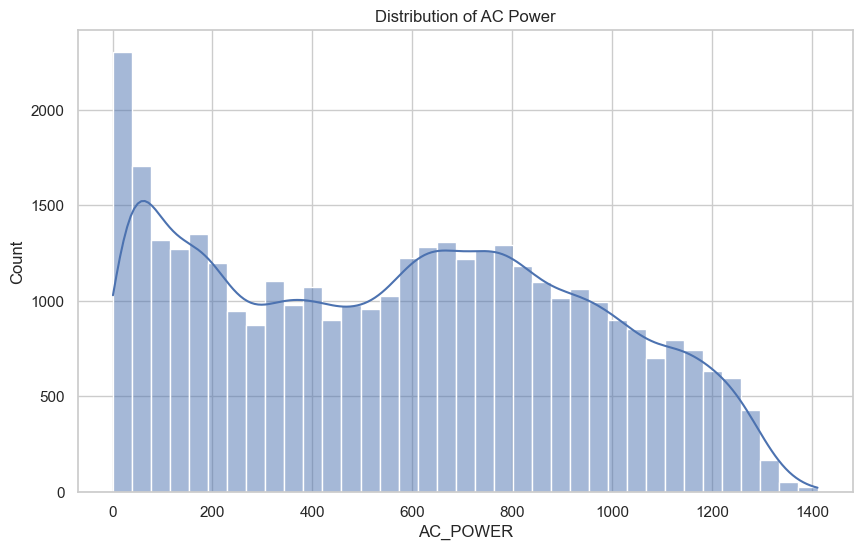

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df["AC_POWER"], kde=True)
plt.title("Distribution of AC Power")
plt.show()


## Feature Selection

The deployed model keeps three input variables:
- `DC_POWER`
- `DAILY_YIELD`
- `TOTAL_YIELD`

These features are numeric, available at prediction time, and directly related to plant generation.


In [26]:
features = ["DC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]
X = df[features].copy()
y = df["AC_POWER"].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


Feature matrix shape: (36827, 3)
Target vector shape: (36827,)


## Train-Test Split and Scaling

The data is split into training and test sets, then standardized with `StandardScaler` so the regression algorithms train on comparable numeric scales.


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")


Training rows: 29,461
Test rows: 7,366


## Model Training

The next cell trains the three required supervised models and compares them with RMSE on the held-out test data.


In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=8,
        random_state=42,
    ),
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = rmse

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["RMSE"]).sort_values("RMSE")
display(results_df)


,RMSE
Random Forest,0.682963
Linear Regression,1.191036
Decision Tree,1.693576


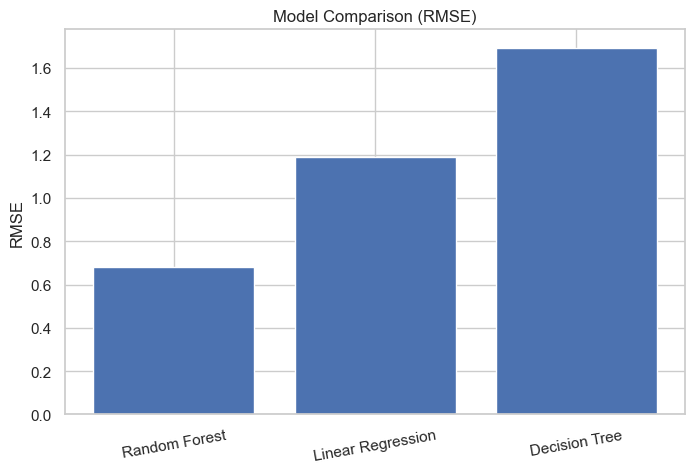

In [29]:
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df["RMSE"])
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=10)
plt.show()


## Gradient Descent and Loss Curve

To satisfy the gradient descent requirement, the next cell trains a linear regression model with `SGDRegressor`, which optimizes squared error iteratively.
The train and test loss curves help show whether the model is converging well across epochs.


Gradient descent linear regression RMSE: 1.1918


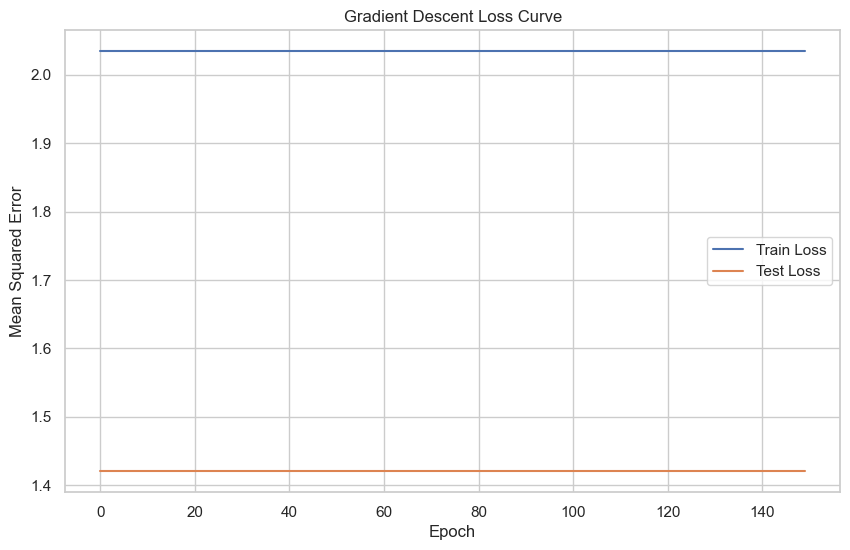

In [30]:
train_losses = []
test_losses = []

sgd = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="invscaling",
    eta0=0.01,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=42,
)

epochs = 150
for epoch in range(epochs):
    sgd.fit(X_train_scaled, y_train)

    y_train_pred = sgd.predict(X_train_scaled)
    y_test_pred = sgd.predict(X_test_scaled)

    train_losses.append(mean_squared_error(y_train, y_train_pred))
    test_losses.append(mean_squared_error(y_test, y_test_pred))

sgd_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Gradient descent linear regression RMSE: {sgd_test_rmse:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Loss Curve")
plt.legend()
plt.show()


## Linear Regression Visualization

Because the deployed model is multivariate, the next cell uses the strongest single predictor, `DC_POWER`, to show a fitted linear regression line passing through the data.
It also keeps an actual-vs-predicted view for the multivariate linear regression model.


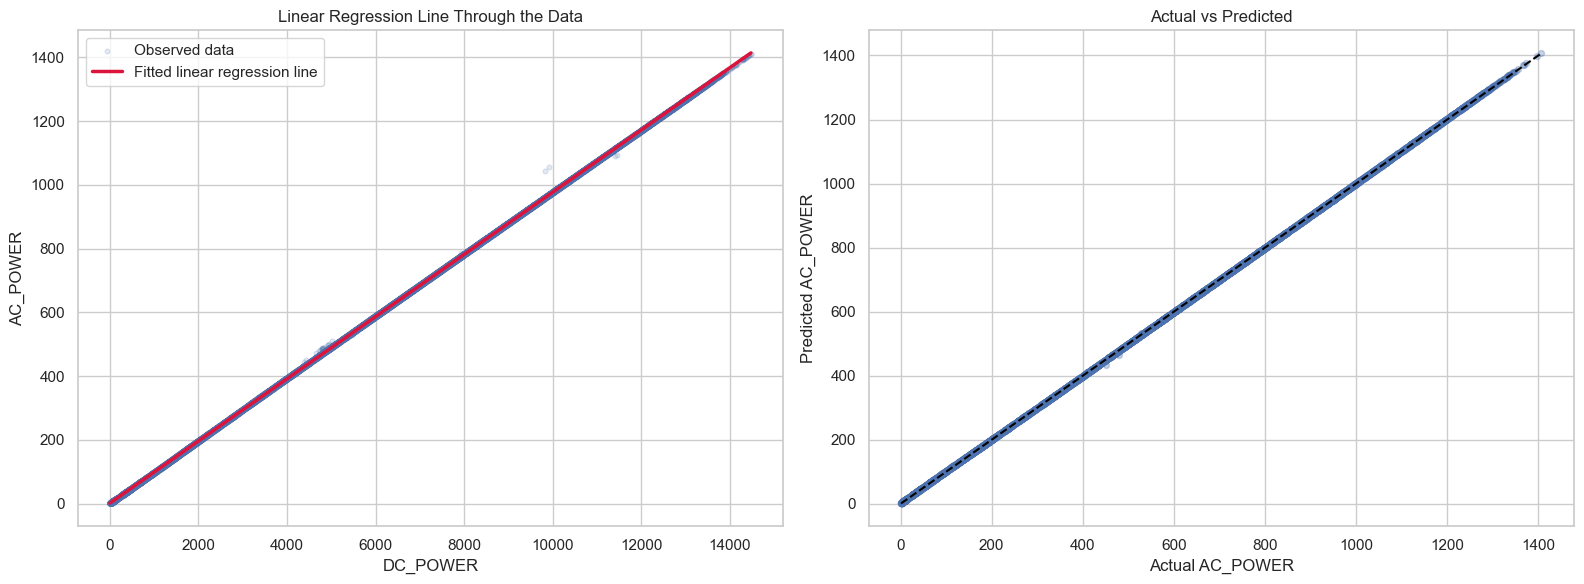

In [31]:
lr_model = models["Linear Regression"]
y_pred_lr = lr_model.predict(X_test_scaled)

line_df = df[["DC_POWER", "AC_POWER"]].sort_values("DC_POWER").copy()
line_model = LinearRegression()
line_model.fit(line_df[["DC_POWER"]], line_df["AC_POWER"])
line_predictions = line_model.predict(line_df[["DC_POWER"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    line_df["DC_POWER"],
    line_df["AC_POWER"],
    alpha=0.15,
    s=12,
    label="Observed data",
)
axes[0].plot(
    line_df["DC_POWER"],
    line_predictions,
    color="crimson",
    linewidth=2.5,
    label="Fitted linear regression line",
)
axes[0].set_xlabel("DC_POWER")
axes[0].set_ylabel("AC_POWER")
axes[0].set_title("Linear Regression Line Through the Data")
axes[0].legend()

axes[1].scatter(y_test, y_pred_lr, alpha=0.3, s=18)
plot_limits = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
axes[1].plot(plot_limits, plot_limits, linestyle="--", color="black", linewidth=1.5)
axes[1].set_xlabel("Actual AC_POWER")
axes[1].set_ylabel("Predicted AC_POWER")
axes[1].set_title("Actual vs Predicted")

plt.tight_layout()
plt.show()


## Save Model


In [32]:
best_model_name = min(results, key=results.get)
best_model = models[best_model_name]

print(f"Saving best model: {best_model_name}")
joblib.dump(best_model, ARTIFACT_DIR / "best_model.pkl", compress=3)
joblib.dump(scaler, ARTIFACT_DIR / "scaler.pkl", compress=3)
joblib.dump(features, ARTIFACT_DIR / "features.pkl")


Saving best model: Random Forest


['features.pkl']

## Feature Importance


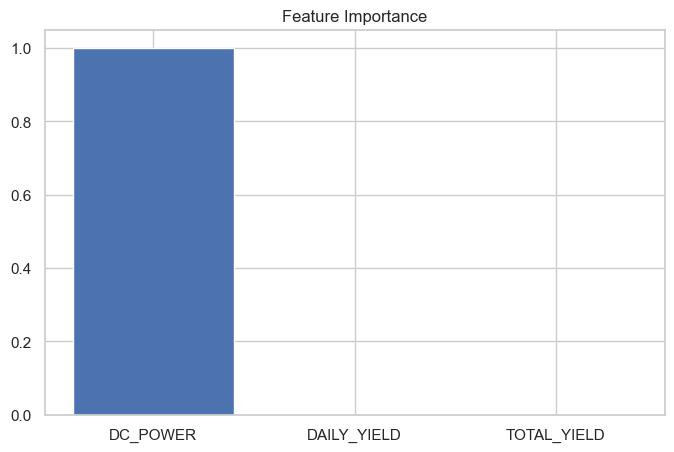

In [33]:
rf = models["Random Forest"]
importances = rf.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()


## Making Predictions


In [34]:
loaded_model = joblib.load(ARTIFACT_DIR / "best_model.pkl")
loaded_scaler = joblib.load(ARTIFACT_DIR / "scaler.pkl")
loaded_features = joblib.load(ARTIFACT_DIR / "features.pkl")

sample_index = X_test.index[0]
sample_input = X_test.loc[[sample_index], loaded_features]
actual_value = y_test.loc[sample_index]

input_scaled = loaded_scaler.transform(sample_input)
prediction = loaded_model.predict(input_scaled)[0]

print("Test row features:", sample_input.to_dict(orient="records")[0])
print(f"Actual AC Power: {actual_value:.4f}")
print(f"Predicted AC Power: {prediction:.4f}")
print(f"Absolute Error: {abs(actual_value - prediction):.4f}")


Test row features: {'DC_POWER': 1460.75, 'DAILY_YIELD': 62.25, 'TOTAL_YIELD': 7249601.25}
Actual AC Power: 142.5875
Predicted AC Power: 142.6685
Absolute Error: 0.0810


## Summary

- Random Forest performed best on the held-out test data based on RMSE.
- `DC_POWER` is the strongest driver of `AC_POWER` in both the correlation analysis and the fitted-line visualization.
- The data was cleaned through numeric conversion, missing-value removal, daytime filtering, feature selection, and standardization.
- Gradient descent convergence was monitored with train and test loss curves before saving the best-performing model for deployment.
